# LGM IRS XVA Examples

This notebook computes a simplified XVA stack (CVA/DVA/FVA) for stylized fixed-for-float IRS trades under 1F LGM simulation.

- The default example is a USD SOFR swap.
- A second example shows the same workflow for EUR.
- Curves are provided explicitly as `(time, zero_rate)` pairs.
- Swap pricing logic is imported from `py_ore_tools.irs_xva_utils`.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from py_ore_tools.lgm import LGMParams, LGM1F, simulate_lgm_measure
from py_ore_tools.irs_xva_utils import (
    build_discount_curve_from_zero_rate_pairs,
    build_swap_schedules,
    build_irregular_exposure_grid,
    payer_swap_npv_at_time,
    par_rate_from_trade,
)

In [2]:
# 1) Build LGM model + reusable IRS/XVA runner
params = LGMParams(
    alpha_times=(0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0),
    alpha_values=(0.010, 0.013, 0.017, 0.021, 0.019, 0.016, 0.014, 0.011),
    kappa_times=(1.0, 4.0, 8.0),
    kappa_values=(0.040, 0.030, 0.022, 0.018),
    shift=0.0,
    scaling=1.0,
)
model = LGM1F(params)


def build_swap_trade(currency, float_index, notional=10_000_000.0, maturity=12.0):
    return {
        'TradeType': 'Swap',
        'Envelope': {
            'CounterParty': 'CPTY_A',
            'NettingSetId': 'CPTY_A',
        },
        'SwapData': {
            'Start': 0.0,
            'End': maturity,
            'LegData': [
                {
                    'LegType': 'Fixed',
                    'Payer': True,
                    'Currency': currency,
                    'DayCounter': 'ACT/360',
                    'Frequency': 'Semiannual',
                    'FrontStub': 0.25,
                    'Notional': float(notional),
                    'FixedRate': None,
                },
                {
                    'LegType': 'Floating',
                    'Payer': False,
                    'Currency': currency,
                    'Index': float_index,
                    'DayCounter': 'ACT/360',
                    'Frequency': 'Quarterly',
                    'Notional': float(notional),
                },
            ],
        },
    }


def run_irs_xva_example(name, currency, float_index, zero_rate_curve, n_paths=30000, seed=12345, trade_spread_bps=15.0):
    p0 = build_discount_curve_from_zero_rate_pairs(zero_rate_curve, compounding='continuous')
    r0 = zero_rate_curve[0][1]
    swap_trade = build_swap_trade(currency=currency, float_index=float_index)

    fixed_dates, float_dates, maturity = build_swap_schedules(swap_trade)
    expo_times = np.unique(np.concatenate((build_irregular_exposure_grid(maturity), fixed_dates, float_dates)))

    k_par = par_rate_from_trade(model, p0, fixed_dates, float_dates, swap_trade)
    k_trade = k_par + trade_spread_bps / 10000.0
    swap_trade['SwapData']['LegData'][0]['FixedRate'] = float(k_trade)
    fixed_rate = swap_trade['SwapData']['LegData'][0]['FixedRate']

    rng = np.random.default_rng(seed)
    t0 = time.perf_counter()
    x_paths = simulate_lgm_measure(model, expo_times, n_paths=n_paths, rng=rng, x0=0.0)
    t1 = time.perf_counter()

    npv_paths = np.zeros_like(x_paths)
    for i, t in enumerate(expo_times):
        npv_paths[i] = payer_swap_npv_at_time(model, p0, fixed_dates, float_dates, t, x_paths[i], fixed_rate, swap_trade)

    ee = np.mean(np.maximum(npv_paths, 0.0), axis=1)
    ene = np.mean(np.maximum(-npv_paths, 0.0), axis=1)

    lambda_cpty = 0.020
    lambda_own = 0.015
    recovery_cpty = 0.40
    recovery_own = 0.40
    lgd_cpty = 1.0 - recovery_cpty
    lgd_own = 1.0 - recovery_own
    funding_spread = 0.005

    dt = np.diff(expo_times)
    df = np.exp(-r0 * expo_times)
    sp_c = np.exp(-lambda_cpty * expo_times)
    sp_b = np.exp(-lambda_own * expo_times)
    d_pd_c = sp_c[:-1] - sp_c[1:]
    d_pd_b = sp_b[:-1] - sp_b[1:]

    cva = lgd_cpty * np.sum(df[1:] * ee[1:] * d_pd_c)
    dva = lgd_own * np.sum(df[1:] * ene[1:] * d_pd_b)
    fva = funding_spread * np.sum(df[1:] * ee[1:] * dt)
    t2 = time.perf_counter()

    return {
        'name': name,
        'currency': currency,
        'float_index': float_index,
        'zero_rate_curve': zero_rate_curve,
        'swap_trade': swap_trade,
        'fixed_dates': fixed_dates,
        'float_dates': float_dates,
        'expo_times': expo_times,
        'k_par': float(k_par),
        'k_trade': float(k_trade),
        'n_paths': int(n_paths),
        'x_paths': x_paths,
        'ee': ee,
        'ene': ene,
        'cva': float(cva),
        'dva': float(dva),
        'fva': float(fva),
        'xva_total': float(cva - dva + fva),
        'sim_elapsed_s': float(t1 - t0),
        'total_elapsed_s': float(t2 - t0),
    }


def print_summary(res):
    print(f"{res['name']}")
    print(f"  Currency / index: {res['currency']} / {res['float_index']}")
    print(f"  Curve pillars: {len(res['zero_rate_curve'])}")
    print(
        f"  Fixed coupons: {len(res['fixed_dates'])} Float coupons: {len(res['float_dates'])} "
        f"Exposure nodes: {len(res['expo_times'])}"
    )
    print(f"  Par rate: {res['k_par']:.6f}")
    print(f"  Trade fixed rate: {res['k_trade']:.6f}")
    print(f"  Simulated x paths: shape={res['x_paths'].shape}, elapsed={res['sim_elapsed_s']:.4f}s")
    print(f"  CVA (simplified): {res['cva']:,.2f}")
    print(f"  DVA (simplified): {res['dva']:,.2f}")
    print(f"  FVA (proxy):      {res['fva']:,.2f}")
    print(f"  Total XVA adj:    {res['xva_total']:,.2f}")

In [3]:
# 2) Scenario setup: USD SOFR first, then EUR
usd_sofr_curve = [
    (0.00, 0.0480),
    (0.25, 0.0477),
    (0.50, 0.0473),
    (1.00, 0.0466),
    (2.00, 0.0454),
    (3.00, 0.0445),
    (5.00, 0.0434),
    (7.00, 0.0428),
    (10.0, 0.0422),
    (12.0, 0.0419),
]

eur_curve = [
    (0.00, 0.0300),
    (0.25, 0.0297),
    (0.50, 0.0293),
    (1.00, 0.0287),
    (2.00, 0.0279),
    (3.00, 0.0273),
    (5.00, 0.0265),
    (7.00, 0.0260),
    (10.0, 0.0255),
    (12.0, 0.0252),
]

usd_sofr_cfg = {
    'name': 'USD SOFR IRS XVA example',
    'currency': 'USD',
    'float_index': 'USD-SOFR',
    'zero_rate_curve': usd_sofr_curve,
}

eur_cfg = {
    'name': 'EUR IRS XVA example',
    'currency': 'EUR',
    'float_index': 'EUR-ESTR',
    'zero_rate_curve': eur_curve,
}

In [4]:
# 3) Run both examples
usd_sofr_res = run_irs_xva_example(**usd_sofr_cfg)
eur_res = run_irs_xva_example(**eur_cfg)

print_summary(usd_sofr_res)
print()
print_summary(eur_res)

USD SOFR IRS XVA example
  Currency / index: USD / USD-SOFR
  Curve pillars: 10
  Fixed coupons: 24 Float coupons: 48 Exposure nodes: 65
  Par rate: 0.043273
  Trade fixed rate: 0.044773
  Simulated x paths: shape=(65, 30000), elapsed=0.0161s
  CVA (simplified): 59,389.30
  DVA (simplified): 34,143.62
  FVA (proxy):      27,606.69
  Total XVA adj:    52,852.37

EUR IRS XVA example
  Currency / index: EUR / EUR-ESTR
  Curve pillars: 10
  Fixed coupons: 24 Float coupons: 48 Exposure nodes: 65
  Par rate: 0.025942
  Trade fixed rate: 0.027442
  Simulated x paths: shape=(65, 30000), elapsed=0.0105s
  CVA (simplified): 68,294.69
  DVA (simplified): 39,116.19
  FVA (proxy):      31,761.74
  Total XVA adj:    60,940.25


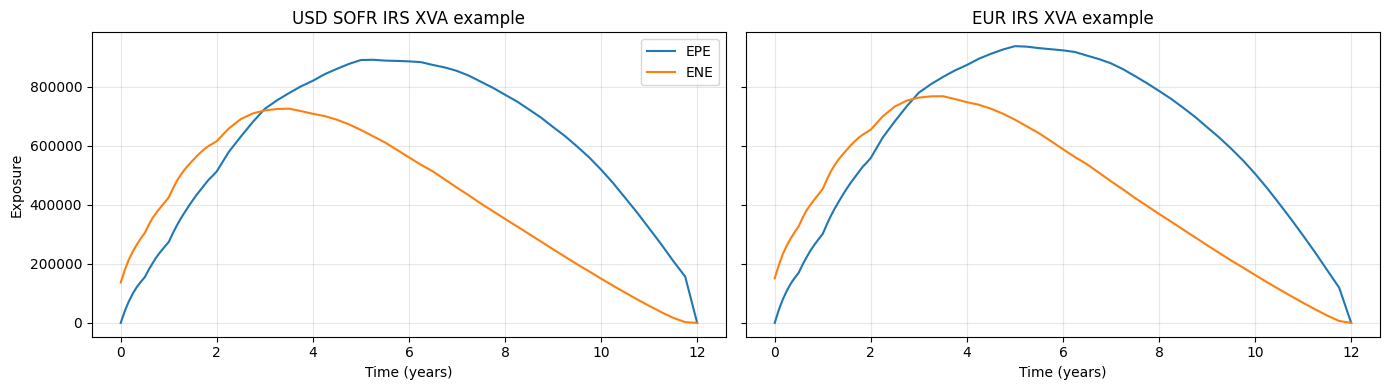

In [5]:
# 4) Exposure profiles
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, res in zip(axes, (usd_sofr_res, eur_res)):
    ax.plot(res['expo_times'], res['ee'], label='EPE')
    ax.plot(res['expo_times'], res['ene'], label='ENE')
    ax.set_title(res['name'])
    ax.set_xlabel('Time (years)')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Exposure')
axes[0].legend()
plt.tight_layout()
plt.show()

In [6]:
# 5) XVA comparison
for res in (usd_sofr_res, eur_res):
    print(f"{res['name']}")
    print(f"  CVA: {res['cva']:,.2f}")
    print(f"  DVA: {res['dva']:,.2f}")
    print(f"  FVA: {res['fva']:,.2f}")
    print(f"  Total XVA: {res['xva_total']:,.2f}")
    print()

USD SOFR IRS XVA example
  CVA: 59,389.30
  DVA: 34,143.62
  FVA: 27,606.69
  Total XVA: 52,852.37

EUR IRS XVA example
  CVA: 68,294.69
  DVA: 39,116.19
  FVA: 31,761.74
  Total XVA: 60,940.25



In [7]:
# 6) End-to-end performance counter

def run_full_xva(config, n_paths=10000, seed=12345):
    return run_irs_xva_example(**config, n_paths=n_paths, seed=seed)

for cfg in (usd_sofr_cfg, eur_cfg):
    perf = run_full_xva(cfg, n_paths=10000)
    print(perf['name'])
    print(f"  elapsed_s: {perf['total_elapsed_s']:.4f}s")
    print(f"  xva_total: {perf['xva_total']:,.2f}")
    print()

USD SOFR IRS XVA example
  elapsed_s: 0.2002s
  xva_total: 53,523.48

EUR IRS XVA example
  elapsed_s: 0.1800s
  xva_total: 61,715.39



In [8]:
# 7) Trade-level comparison snapshot
print('Name'.ljust(28), 'ParRate', 'TradeRate', 'Paths')
for res in (usd_sofr_res, eur_res):
    print(
        res['name'].ljust(28),
        f"{res['k_par']:.6f}",
        f"{res['k_trade']:.6f}",
        res['n_paths'],
    )

Name                         ParRate TradeRate Paths
USD SOFR IRS XVA example     0.043273 0.044773 30000
EUR IRS XVA example          0.025942 0.027442 30000


In [9]:
# 8) Access the result objects directly if you want to inspect arrays
usd_sofr_res.keys(), eur_res.keys()

(dict_keys(['name', 'currency', 'float_index', 'zero_rate_curve', 'swap_trade', 'fixed_dates', 'float_dates', 'expo_times', 'k_par', 'k_trade', 'n_paths', 'x_paths', 'ee', 'ene', 'cva', 'dva', 'fva', 'xva_total', 'sim_elapsed_s', 'total_elapsed_s']),
 dict_keys(['name', 'currency', 'float_index', 'zero_rate_curve', 'swap_trade', 'fixed_dates', 'float_dates', 'expo_times', 'k_par', 'k_trade', 'n_paths', 'x_paths', 'ee', 'ene', 'cva', 'dva', 'fva', 'xva_total', 'sim_elapsed_s', 'total_elapsed_s']))

## 9) FX Forward Examples (LGM+FX Hybrid)

This section adds two standalone FX forward examples using the hybrid LGM+FX layer:
- GBP/USD 1Y forward
- USD/CAD 2Y forward


In [10]:
import sys
from pathlib import Path

TOOLS_DIR = Path('/Users/gordonlee/Documents/Engine/Tools/PythonOreRunner/py_ore_tools')
if str(TOOLS_DIR) not in sys.path:
    sys.path.insert(0, str(TOOLS_DIR))

import importlib
import lgm_fx_xva_utils as fxu
fxu = importlib.reload(fxu)
run_fx_forward_example = fxu.run_fx_forward_example

fx_ex_1 = run_fx_forward_example(
    name='FXFWD_GBPUSD_1Y',
    pair='GBP/USD',
    maturity=1.0,
    spot0=1.2700,
    strike=1.2850,
    notional_base=10_000_000,
    dom_zero_rate=[(0.0, 0.0475), (30.0, 0.0475)],
    for_zero_rate=[(0.0, 0.0400), (30.0, 0.0400)],
    fx_vol={'times': (), 'values': (0.115,)},
    alpha_dom={'times': (1.0, 3.0, 7.0), 'values': (0.010, 0.010, 0.010, 0.010)},
    alpha_for=((), (0.010,)),
    kappa_dom=0.03,
    kappa_for=0.03,
    corr_dom_fx=-0.15,
    corr_for_fx=0.10,
    n_paths=20000,
    seed=1234,
)

fx_ex_2 = run_fx_forward_example(
    name='FXFWD_USDCAD_2Y',
    pair='USD/CAD',
    maturity=2.0,
    spot0=1.3400,
    strike=1.3600,
    notional_base=10_000_000,
    dom_zero_rate=[(0.0, 0.0360), (30.0, 0.0360)],
    for_zero_rate=[(0.0, 0.0475), (30.0, 0.0475)],
    fx_vol=0.105,
    alpha_dom=0.010,
    alpha_for=0.010,
    kappa_dom=0.03,
    kappa_for=0.03,
    corr_dom_fx=-0.05,
    corr_for_fx=0.05,
    n_paths=20000,
    seed=5678,
)

for r in (fx_ex_1, fx_ex_2):
    print(f"{r['name']} ({r['pair']}, {r['maturity']}Y)")
    print(f"  spot0={r['spot0']:.6f} strike={r['strike']:.6f} fwd0={r['fwd0']:.6f}")
    print(f"  t0 NPV (deterministic): {r['npv0']:,.2f}")
    print(f"  terminal MTM mean:      {r['mtm_at_maturity_mean']:,.2f}")
    print(f"  terminal MTM P05/P95:   {r['mtm_at_maturity_p05']:,.2f} / {r['mtm_at_maturity_p95']:,.2f}")

fx_examples = [fx_ex_1, fx_ex_2]


FXFWD_GBPUSD_1Y (GBP/USD, 1.0Y)
  spot0=1.270000 strike=1.285000 fwd0=1.279561
  t0 NPV (deterministic): -51,868.70
  terminal MTM mean:      -58,114.96
  terminal MTM P05/P95:   -2,307,748.47 / 2,465,628.16
FXFWD_USDCAD_2Y (USD/CAD, 2.0Y)
  spot0=1.340000 strike=1.360000 fwd0=1.309532
  t0 NPV (deterministic): -469,622.86
  terminal MTM mean:      -514,383.88
  terminal MTM P05/P95:   -3,452,838.39 / 2,916,830.09


## 10) FX Forward Profiles and XVA

Compute full pathwise profiles for the same FX forward examples and derive a simple XVA stack:
- Exposure profiles: `EE`, `EPE`, `ENE`
- `CVA`, `DVA`, `FVA`, and `Total = CVA - DVA + FVA`


FXFWD_GBPUSD_1Y (GBP/USD)
  CVA=3,200.15  DVA=2,403.07  FVA=5.35  Total=802.43
FXFWD_USDCAD_2Y (USD/CAD)
  CVA=5,599.83  DVA=9,287.17  FVA=9.39  Total=-3,677.95


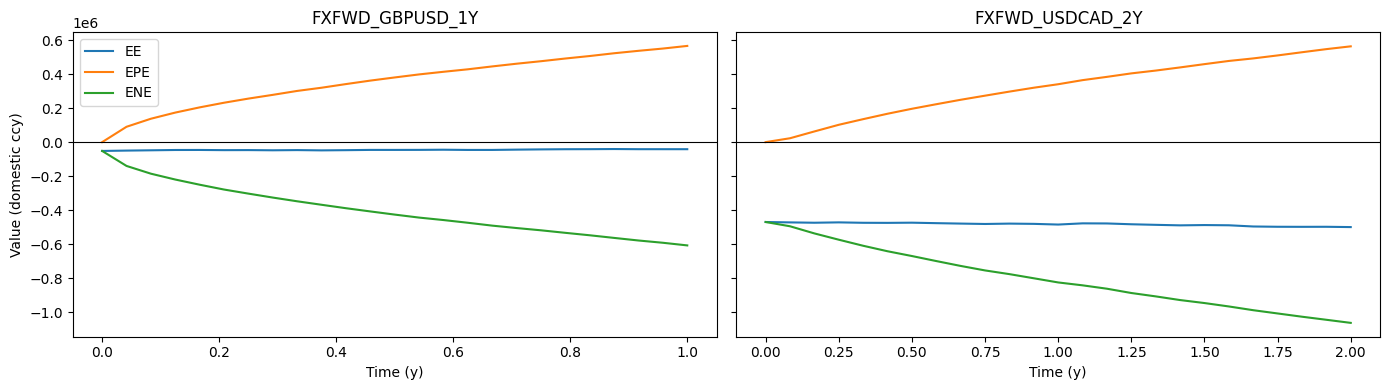

In [11]:
import matplotlib.pyplot as plt
import sys
from pathlib import Path

TOOLS_DIR = Path('/Users/gordonlee/Documents/Engine/Tools/PythonOreRunner/py_ore_tools')
if str(TOOLS_DIR) not in sys.path:
    sys.path.insert(0, str(TOOLS_DIR))

import importlib
import lgm_fx_xva_utils as fxu
fxu = importlib.reload(fxu)
run_fx_forward_profile_xva = fxu.run_fx_forward_profile_xva

fx_prof_1 = run_fx_forward_profile_xva(
    name='FXFWD_GBPUSD_1Y',
    pair='GBP/USD',
    maturity=1.0,
    spot0=1.2700,
    strike=1.2850,
    notional_base=10_000_000,
    dom_zero_rate=[(0.0, 0.0475), (30.0, 0.0475)],
    for_zero_rate=[(0.0, 0.0400), (30.0, 0.0400)],
    fx_vol={'times': (), 'values': (0.115,)},
    alpha_dom={'times': (1.0, 3.0, 7.0), 'values': (0.010, 0.010, 0.010, 0.010)},
    alpha_for=((), (0.010,)),
    kappa_dom=0.03,
    kappa_for=0.03,
    corr_dom_fx=-0.15,
    corr_for_fx=0.10,
    n_paths=25000,
    seed=1234,
)

fx_prof_2 = run_fx_forward_profile_xva(
    name='FXFWD_USDCAD_2Y',
    pair='USD/CAD',
    maturity=2.0,
    spot0=1.3400,
    strike=1.3600,
    notional_base=10_000_000,
    dom_zero_rate=[(0.0, 0.0360), (30.0, 0.0360)],
    for_zero_rate=[(0.0, 0.0475), (30.0, 0.0475)],
    fx_vol=0.105,
    alpha_dom=0.010,
    alpha_for=0.010,
    kappa_dom=0.03,
    kappa_for=0.03,
    corr_dom_fx=-0.05,
    corr_for_fx=0.05,
    n_paths=25000,
    seed=5678,
)

for r in (fx_prof_1, fx_prof_2):
    print(f"{r['name']} ({r['pair']})")
    print(f"  CVA={r['cva']:,.2f}  DVA={r['dva']:,.2f}  FVA={r['fva']:,.2f}  Total={r['xva_total']:,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, r in zip(axes, (fx_prof_1, fx_prof_2)):
    ax.plot(r['times'], r['ee'], label='EE')
    ax.plot(r['times'], r['epe'], label='EPE')
    ax.plot(r['times'], r['ene'], label='ENE')
    ax.axhline(0.0, color='black', lw=0.8)
    ax.set_title(r['name'])
    ax.set_xlabel('Time (y)')
axes[0].set_ylabel('Value (domestic ccy)')
axes[0].legend(loc='best')
plt.tight_layout()
plt.show()

fx_profiles = [fx_prof_1, fx_prof_2]


## 11) Cap/Floor Example (Utility-Only)

Build a cap profile under LGM using `lgm_ir_options` only (no inline pricing logic).


CAP_EUR_2Y: PV0=58,479.63  CVA=715.86


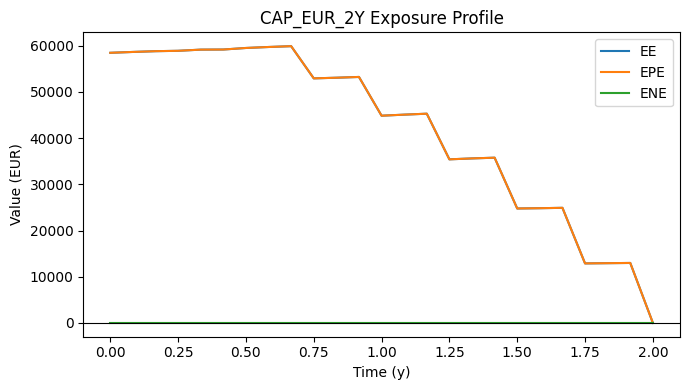

In [12]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

TOOLS_DIR = Path('/Users/gordonlee/Documents/Engine/Tools/PythonOreRunner/py_ore_tools')
if str(TOOLS_DIR) not in sys.path:
    sys.path.insert(0, str(TOOLS_DIR))

import lgm as lgm_mod
import lgm_ir_options as iro
import lgm_fx_xva_utils as xva_mod
import irs_xva_utils as irs_mod

lgm_mod = importlib.reload(lgm_mod)
iro = importlib.reload(iro)
xva_mod = importlib.reload(xva_mod)
irs_mod = importlib.reload(irs_mod)

LGM1F = lgm_mod.LGM1F
LGMParams = lgm_mod.LGMParams
simulate_lgm_measure = lgm_mod.simulate_lgm_measure
CapFloorDef = iro.CapFloorDef
capfloor_npv_paths = iro.capfloor_npv_paths
aggregate_exposure_profile = xva_mod.aggregate_exposure_profile
cva_terms_from_profile = xva_mod.cva_terms_from_profile
build_discount_curve_from_zero_rate_pairs = irs_mod.build_discount_curve_from_zero_rate_pairs
survival_probability_from_hazard = irs_mod.survival_probability_from_hazard

params = LGMParams(
    alpha_times=(1.0, 3.0, 7.0),
    alpha_values=(0.010, 0.010, 0.009, 0.008),
    kappa_times=(),
    kappa_values=(0.03,),
    shift=0.0,
    scaling=1.0,
)
model = LGM1F(params)

maturity = 2.0
times = np.linspace(0.0, maturity, 25)
rng = np.random.default_rng(2026)
x_paths = simulate_lgm_measure(model, times, n_paths=20000, rng=rng)

p0 = build_discount_curve_from_zero_rate_pairs([(0.0, 0.03), (30.0, 0.03)])

# Quarterly coupons on [0.5, 2.0]
start = np.arange(0.5, 2.0, 0.25)
end = start + 0.25
pay = end.copy()
acc = np.full_like(start, 0.25)
notional = np.full_like(start, 10_000_000.0)
strike = np.full_like(start, 0.03)

cap_def = CapFloorDef(
    trade_id='CAP_EUR_2Y',
    ccy='EUR',
    option_type='cap',
    start_time=start,
    end_time=end,
    pay_time=pay,
    accrual=acc,
    notional=notional,
    strike=strike,
    fixing_time=start,
    position=1.0,
)

cap_npv_paths = capfloor_npv_paths(model, p0, p0, cap_def, times, x_paths, lock_fixings=True)
cap_exp = aggregate_exposure_profile(cap_npv_paths)

q = survival_probability_from_hazard(times, np.array([10.0]), np.array([0.015]))
df = np.asarray([p0(float(t)) for t in times], dtype=float)
cap_cva = float(cva_terms_from_profile(times, cap_exp['epe'], df, q, recovery=0.4)['cva'][0])

print(f"CAP_EUR_2Y: PV0={np.mean(cap_npv_paths[0]):,.2f}  CVA={cap_cva:,.2f}")

plt.figure(figsize=(7, 4))
plt.plot(times, cap_exp['ee'], label='EE')
plt.plot(times, cap_exp['epe'], label='EPE')
plt.plot(times, cap_exp['ene'], label='ENE')
plt.axhline(0.0, color='black', lw=0.8)
plt.title('CAP_EUR_2Y Exposure Profile')
plt.xlabel('Time (y)')
plt.ylabel('Value (EUR)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()



## 12) Bermudan Swaption Example (Utility-Only)

Price and profile a Bermudan swaption with LSMC via `lgm_ir_options`.


BERM_EUR_5Y: PV0=12,575.65  CVA=386.34


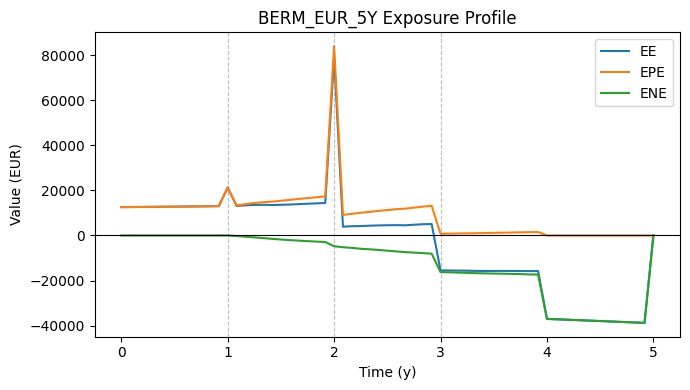

In [13]:
import numpy as np
import matplotlib.pyplot as plt

BermudanSwaptionDef = iro.BermudanSwaptionDef
bermudan_npv_paths = iro.bermudan_npv_paths
bermudan_price = iro.bermudan_price

# Simple underlying payer swap (receive float, pay fixed)
fixed_pay = np.array([2.0, 3.0, 4.0, 5.0])
float_start = np.array([1.0, 2.0, 3.0, 4.0])
float_end = np.array([2.0, 3.0, 4.0, 5.0])

legs = {
    'fixed_pay_time': fixed_pay,
    'fixed_accrual': np.ones_like(fixed_pay),
    'fixed_rate': np.full_like(fixed_pay, 0.032),
    'fixed_notional': np.full_like(fixed_pay, 10_000_000.0),
    'fixed_sign': np.full_like(fixed_pay, -1.0),
    'fixed_amount': np.full_like(fixed_pay, -320_000.0),
    'float_pay_time': float_end,
    'float_start_time': float_start,
    'float_end_time': float_end,
    'float_accrual': np.ones_like(float_end),
    'float_notional': np.full_like(float_end, 10_000_000.0),
    'float_sign': np.full_like(float_end, 1.0),
    'float_spread': np.zeros_like(float_end),
    'float_coupon': np.zeros_like(float_end),
}

berm = BermudanSwaptionDef(
    trade_id='BERM_EUR_5Y',
    exercise_times=np.array([1.0, 2.0, 3.0]),
    underlying_legs=legs,
    exercise_sign=1.0,
)

times_b = np.linspace(0.0, 5.0, 61)
rng_b = np.random.default_rng(777)
x_b = simulate_lgm_measure(model, times_b, n_paths=30000, rng=rng_b)

berm_paths = bermudan_npv_paths(model, p0, p0, berm, times_b, x_b, basis_degree=2, itm_only=True)
berm_pv0 = bermudan_price(model, p0, p0, berm, times_b, x_b, basis_degree=2, itm_only=True)
berm_exp = aggregate_exposure_profile(berm_paths)

q_b = survival_probability_from_hazard(times_b, np.array([10.0]), np.array([0.015]))
df_b = np.asarray([p0(float(t)) for t in times_b], dtype=float)
berm_cva = float(cva_terms_from_profile(times_b, berm_exp['epe'], df_b, q_b, recovery=0.4)['cva'][0])

print(f"BERM_EUR_5Y: PV0={berm_pv0:,.2f}  CVA={berm_cva:,.2f}")

plt.figure(figsize=(7, 4))
plt.plot(times_b, berm_exp['ee'], label='EE')
plt.plot(times_b, berm_exp['epe'], label='EPE')
plt.plot(times_b, berm_exp['ene'], label='ENE')
for ex in berm.exercise_times:
    plt.axvline(float(ex), color='gray', lw=0.8, ls='--', alpha=0.5)
plt.axhline(0.0, color='black', lw=0.8)
plt.title('BERM_EUR_5Y Exposure Profile')
plt.xlabel('Time (y)')
plt.ylabel('Value (EUR)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

